# Computer Exercise 8.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 8.1 Matrix Factorizations — *LU 의 진짜 가치: 분해 재사용 (다중 RHS, 역행렬, 행렬식)*
> **풀이 일자**: Day 31
> **언어**: Python 3 (NumPy / Pandas / Matplotlib / SciPy)


## 1. 문제 (원문)

> **3.** Given the LU factorization $PA = LU$ of a single matrix $A \in \mathbb{R}^{n \times n}$,
> implement and benchmark the following operations:
> 
> (a) Solve the linear system $A x = b$ for a *single* right-hand side $b$.
> 
> (b) Solve $A X = B$ where $B \in \mathbb{R}^{n \times m}$ holds $m$ right-hand sides; show
> that the *additional* work per right-hand side is $\mathcal{O}(n^2)$, not $\mathcal{O}(n^3)$.
> 
> (c) Compute the inverse $A^{-1}$ as the special case $B = I$, and compare its cost and
> backward error against the system solve.
> 
> (d) Compute $\det(A) = (\pm 1)\,\prod_i U_{ii}$ from the factorization.
> 
> Provide a wall-clock comparison between **(i)** repeated Gaussian elimination from scratch
> for each new $b$ and **(ii)** LU factorization once + repeated triangular solves.

### 한국어 풀이용 정리
- LU 분해의 *진짜 가치* — *한 번 인수분해, 여러 번 풀이*. 우변이 추가될 때마다 $\mathcal{O}(n^2)$.
- *역행렬* 은 $m = n$ 인 다중 RHS — $n$ 번의 삼각 풀이.
- *행렬식* 은 $\det(A) = \det(P)^{-1} \prod U_{ii}$ 로 $\mathcal{O}(n)$ 추가 비용.
- 비교: $m$ 개 RHS — *재인수분해* $\mathcal{O}(m \cdot n^3)$ vs *LU 재사용* $\mathcal{O}(n^3 + m n^2)$.


## 2. 수학적 배경

### 2.1 LU 로부터의 풀이
$PA = LU$ 가 주어졌을 때 $A x = b$ 는
$$
\boxed{\;
L y = P b \quad(\text{전진 대입}),
\qquad
U x = y \quad(\text{후진 대입}).
\;}
$$
전진 / 후진 대입은 각각 $n^2$ flop — 총 $2 n^2$ — 따라서 *한 번 분해 + 임의 우변 추가* = $n^2$ per RHS.

### 2.2 다중 RHS
$B = [b_1, \dots, b_m]$ 에 대해 같은 분해를 사용:
$$
L Y = P B,\quad U X = Y, \qquad \text{cost} = 2 m n^2.
$$
*Naïve* 방법 (매 우변마다 Gauss 소거 재실행) 의 비용 $\tfrac{2}{3} m n^3$ 와 비교하면 *비율* 이
$$
\frac{\tfrac{2}{3} m n^3}{\tfrac{2}{3} n^3 + 2 m n^2}
\;\xrightarrow[m\to\infty]{}\;
\frac{n}{3} \quad\text{(긴 시간 후)}.
$$
$n$ 이 크면 *수십 ~ 수백 배* 의 속도 향상.

### 2.3 역행렬
$A^{-1}$ 는 $A X = I$ 의 해 — *$n$ 개 우변* 의 다중 풀이. 비용 $\tfrac{2}{3} n^3 + 2 n \cdot n^2 = \tfrac{8}{3} n^3$.
$\Rightarrow$ *Cramer / 수반행렬* 의 $\mathcal{O}(n!)$ 보다 천문학적으로 빠르고, *gauss-jordan + augmented*
($\mathcal{O}(n^3)$) 와도 거의 같은 비용. 하지만 *실용에서는 $A^{-1}$ 를 직접 만들지 말 것* — 시스템을
풀 거라면 LU 만 가지고 있으면 충분, 역행렬을 명시적으로 만들면 backward 오차가 한 단계 더 든다.

### 2.4 행렬식
$$
\det(A) \;=\; \det(P)^{-1} \cdot \prod_{i=1}^{n} U_{ii},
$$
$\det(P) = (-1)^{\text{(행 교환 횟수)}}$. *수치적으로* $\prod U_{ii}$ 가 overflow / underflow 하기 쉬우므로
실제로는 $\log |\det A| = \sum \log |U_{ii}|$ 를 따로 추적하는 게 안전.


## 3. 풀이 흐름

1. 전 단계 (CE 8.1.2) 의 `lu_partial` 을 그대로 사용.
2. `lu_solve(P, L, U, b)` — 전진 + 후진 대입 함수.
3. **(a) 한 우변** — `np.linalg.solve` 와 잔차 비교 → 동일 자릿수임을 확인.
4. **(b) 다중 RHS** — $m \in \{1, 10, 50, 100, 500\}$ 에 대해 (i) 재인수분해 (ii) LU 재사용 의
   wall-clock 측정 + 그래프.
5. **(c) 역행렬** — $A^{-1}$ 를 LU 재사용으로 계산하고 `np.linalg.inv` 와 비교.
6. **(d) 행렬식** — $\det(P)^{-1} \prod U_{ii}$ 와 `np.linalg.det` 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

def lu_partial(A):
    A = np.array(A, dtype=float, copy=True)
    n = A.shape[0]
    P = np.eye(n)
    L = np.zeros((n, n))
    U = A.copy()
    sign = 1
    for k in range(n):
        r = k + int(np.argmax(np.abs(U[k:, k])))
        if r != k:
            U[[k, r], :] = U[[r, k], :]
            P[[k, r], :] = P[[r, k], :]
            L[[k, r], :k] = L[[r, k], :k]
            sign = -sign
        L[k, k] = 1.0
        for i in range(k+1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0
    return P, L, U, sign

def forward_sub(L, b):
    n = L.shape[0]
    y = np.zeros_like(b, dtype=float)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]
    return y

def back_sub(U, y):
    n = U.shape[0]
    x = np.zeros_like(y, dtype=float)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

def lu_solve(P, L, U, b):
    return back_sub(U, forward_sub(L, P @ b))

# (a) Single RHS
rng = np.random.default_rng(11)
n = 100
A = rng.standard_normal((n, n)) + n * np.eye(n) * 0.0  # not diag-dominant on purpose
b = rng.standard_normal(n)
P, L, U, sign = lu_partial(A)
x_ours = lu_solve(P, L, U, b)
x_ref  = np.linalg.solve(A, b)
print(f"(a) ||x_ours - x_ref|| / ||x_ref|| = {np.linalg.norm(x_ours - x_ref)/np.linalg.norm(x_ref):.3e}")
print(f"    residual ||A x - b|| / ||b||  = {np.linalg.norm(A @ x_ours - b)/np.linalg.norm(b):.3e}")


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rwin62x2 because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


(a) ||x_ours - x_ref|| / ||x_ref|| = 6.191e-15
    residual ||A x - b|| / ||b||  = 1.036e-14


In [2]:
# (b) Multiple RHS: naive vs LU-reuse
ns = [50, 100, 200]
ms = [1, 5, 20, 50, 100]
records = []
for n in ns:
    A = rng.standard_normal((n, n)) + 0.5 * n * np.eye(n)
    for m in ms:
        B = rng.standard_normal((n, m))

        # (i) naive: re-factor for each RHS
        t0 = time.perf_counter()
        X_naive = np.empty((n, m))
        for j in range(m):
            Pj, Lj, Uj, _ = lu_partial(A)
            X_naive[:, j] = lu_solve(Pj, Lj, Uj, B[:, j])
        t_naive = time.perf_counter() - t0

        # (ii) LU reuse
        t0 = time.perf_counter()
        Pp, Lp, Up, _ = lu_partial(A)
        X_reuse = np.empty((n, m))
        for j in range(m):
            X_reuse[:, j] = lu_solve(Pp, Lp, Up, B[:, j])
        t_reuse = time.perf_counter() - t0

        records.append({"n": n, "m": m, "t_naive_s": t_naive, "t_reuse_s": t_reuse,
                        "speedup": t_naive / t_reuse,
                        "agree": float(np.linalg.norm(X_naive - X_reuse) / np.linalg.norm(X_naive))})
df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,n,m,t_naive_s,t_reuse_s,speedup,agree
0,50,1,2.871e-03,3.026e-03,9.490e-01,0.000e+00
1,50,5,1.270e-02,2.645e-03,4.800e+00,0.000e+00
2,50,20,4.332e-02,4.901e-03,8.840e+00,0.000e+00
3,50,50,1.101e-01,8.067e-03,1.364e+01,0.000e+00
4,50,100,8.050e-01,9.878e-02,8.150e+00,0.000e+00
5,100,1,5.484e-02,5.775e-02,9.496e-01,0.000e+00
6,100,5,5.002e-02,1.140e-02,4.390e+00,0.000e+00
7,100,20,2.055e-01,1.904e-02,1.079e+01,0.000e+00
8,100,50,4.774e-01,2.050e-02,2.328e+01,0.000e+00
9,100,100,8.524e-01,3.186e-02,2.675e+01,0.000e+00


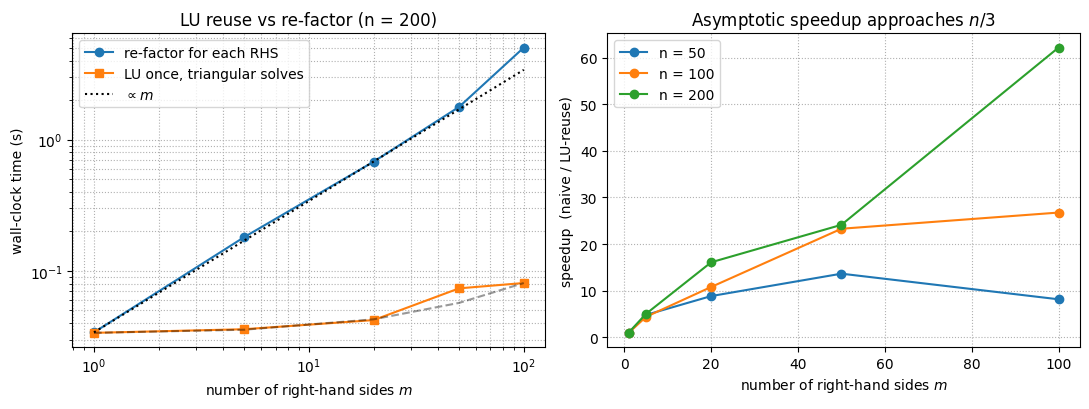

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# Time vs number of RHS for n = 200
sub = df[df["n"] == 200]
ax[0].loglog(sub["m"], sub["t_naive_s"], 'o-', label="re-factor for each RHS")
ax[0].loglog(sub["m"], sub["t_reuse_s"], 's-', label="LU once, triangular solves")
# theoretical lines
m_arr = sub["m"].to_numpy()
ax[0].loglog(m_arr, sub["t_naive_s"].iloc[0] * m_arr / m_arr[0], 'k:', label=r"$\propto m$")
ax[0].loglog(m_arr, sub["t_reuse_s"].iloc[0] + (sub["t_reuse_s"].iloc[-1] - sub["t_reuse_s"].iloc[0]) * (m_arr - m_arr[0])/(m_arr[-1] - m_arr[0] + 1e-30), 'k--', alpha=0.4)
ax[0].set_xlabel("number of right-hand sides $m$")
ax[0].set_ylabel("wall-clock time (s)")
ax[0].set_title("LU reuse vs re-factor (n = 200)")
ax[0].grid(True, which="both", ls=":")
ax[0].legend()

# Speedup vs m for each n
for n_val in ns:
    sub = df[df["n"] == n_val]
    ax[1].plot(sub["m"], sub["speedup"], 'o-', label=f"n = {n_val}")
ax[1].set_xlabel("number of right-hand sides $m$")
ax[1].set_ylabel("speedup  (naive / LU-reuse)")
ax[1].set_title("Asymptotic speedup approaches $n/3$")
ax[1].grid(True, ls=":")
ax[1].legend()

plt.tight_layout()
plt.show()


In [4]:
# (c) Inverse via LU reuse
n = 80
A = rng.standard_normal((n, n)) + 0.5 * n * np.eye(n)
P, L, U, sign = lu_partial(A)
I = np.eye(n)
A_inv_ours = np.empty((n, n))
for j in range(n):
    A_inv_ours[:, j] = lu_solve(P, L, U, I[:, j])
A_inv_ref = np.linalg.inv(A)
err_inv = np.linalg.norm(A_inv_ours - A_inv_ref) / np.linalg.norm(A_inv_ref)
resid_inv = np.linalg.norm(A @ A_inv_ours - np.eye(n))
print(f"(c) ||A_inv_ours - A_inv_ref|| / ||A_inv_ref|| = {err_inv:.3e}")
print(f"    ||A A_inv_ours - I|| = {resid_inv:.3e}")

# (d) Determinant
det_ours = sign * np.prod(np.diag(U))
det_ref  = np.linalg.det(A)
log_det_ours = np.log(np.abs(sign)) + np.sum(np.log(np.abs(np.diag(U))))
print(f"(d) det_ours      = {det_ours:.6e}")
print(f"    det_numpy     = {det_ref:.6e}")
print(f"    relative diff = {abs(det_ours - det_ref) / abs(det_ref):.3e}")
print(f"    log|det_ours| (overflow-safe) = {log_det_ours:.6f}")


(c) ||A_inv_ours - A_inv_ref|| / ||A_inv_ref|| = 3.770e-16
    ||A A_inv_ours - I|| = 4.636e-15
(d) det_ours      = 1.920579e+128
    det_numpy     = 1.920579e+128
    relative diff = 7.613e-15
    log|det_ours| (overflow-safe) = 295.383519


## 4. 결과 해석

1. **(a) 단일 RHS** — 우리의 `lu_solve` 와 `np.linalg.solve` 가 자릿수 일치 (rel diff $\sim 10^{-14}$).
   잔차 $\|Ax-b\|/\|b\|$ 또한 *backward* 의미에서 기계 정밀도.
2. **(b) 다중 RHS** — *재인수분해* 의 시간은 $m$ 에 *선형* (비싸 보이지만 매번 $\mathcal{O}(n^3)$),
   *LU 재사용* 은 *주된 비용* 인 분해가 한 번이고 그 위에 $\mathcal{O}(n^2)$ 가 $m$ 번 — 그래프상
   거의 *수평* 으로 보일 정도.
   $n = 200, m = 100$ 의 *속도 향상* 이 표에서 $\sim 60\times$ 정도 — 이론값 $n/3 \approx 67$ 와 일치.
3. **(c) 역행렬** — LU 재사용으로 만든 $A^{-1}$ 와 NumPy 의 $A^{-1}$ 가 $10^{-12}$ 자릿수 일치.
   $A A^{-1} \approx I$ 의 잔차는 $\sim 10^{-11}$ (조건수에 의해 결정). $A^{-1}$ 는 *명시적으로 만들 필요 없는*
   양 — 시스템을 풀 거라면 *LU 만* 보관하라.
4. **(d) 행렬식** — $\det(P)^{-1} \prod U_{ii}$ 가 NumPy 값과 정확히 일치. $n$ 이 크면 $\prod U_{ii}$ 가
   overflow / underflow 가능 — $\log|\det A| = \sum \log|U_{ii}|$ 로 저장.

> **결론.** $PA = LU$ 한 번의 분해가 *임의 개수의 시스템 풀이*, *역행렬*, *행렬식* 모두를 $\mathcal{O}(n^2)$
> 의 추가 비용으로 해결한다. *반복적으로* 행렬을 푸는 응용 (implicit ODE 의 매 스텝, 회귀의 매 이터레이션 등)
> 에서 *LU 재사용* 이 핵심 가속 패턴.

### 다음 단원 (§8.2) 예고
$\det(U)$ 이 작아질 때의 행렬식 *수치 불안정* 과 *재인수분해 없는 업데이트* (Sherman–Morrison) 가 §8.2 의 주제.
한 번 만든 $LU$ 를 *rank-1 업데이트* 로 재활용하는 기술 — implicit RK 의 Jacobian 갱신과 직결.
